In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [3]:
import sys
sys.path.append(working_directory)

import logging
import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from sctram.generate.real import sc_norman_sciplex_cpa

sc.settings.verbosity = 3

In [4]:
from sctram.infer._dpt import DPTInference
from sctram.evaluate._pseudotime import PseudotimeValuesEvaluation
from sctram.input import InputTrajectories

In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
dataset_dir = "/Users/kemalinecik/git_nosync/sctram/__temp__/data"
adata_norman = sc_norman_sciplex_cpa(dataset_dir=dataset_dir)
adata_bms = adata_norman[["bms" in i.lower() or "vehicle" in i.lower() for i in adata_norman.obs["drug"]]]

2025-03-07 18:11:56.993 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/Users/kemalinecik/git_nosync/sctram/__temp__/data/norman_sciplex_cpa.h5ad') already exists. Skipping download.


# Input

In [7]:
ground_truth_trajectories = {
    "trajectory_1": [
        ('Vehicle_1.0', 'BMS_0.001'),
        ('BMS_0.001', 'BMS_0.005'),
        ('BMS_0.005', 'BMS_0.01'),
        ('BMS_0.01', 'BMS_0.05'),
        ('BMS_0.05', 'BMS_0.1'),
        ('BMS_0.1', 'BMS_0.5'),
        ('BMS_0.5', 'BMS_1.0'),
    ],
}
input_trajectories_all = InputTrajectories(ground_truth_trajectories)
input_trajectories = input_trajectories_all.get_trajectory("trajectory_1", include_additional_nodes=False)

In [8]:
np.array(input_trajectories.nodes())

array(['Vehicle_1.0', 'BMS_0.001', 'BMS_0.005', 'BMS_0.01', 'BMS_0.05',
       'BMS_0.1', 'BMS_0.5', 'BMS_1.0'], dtype='<U11')

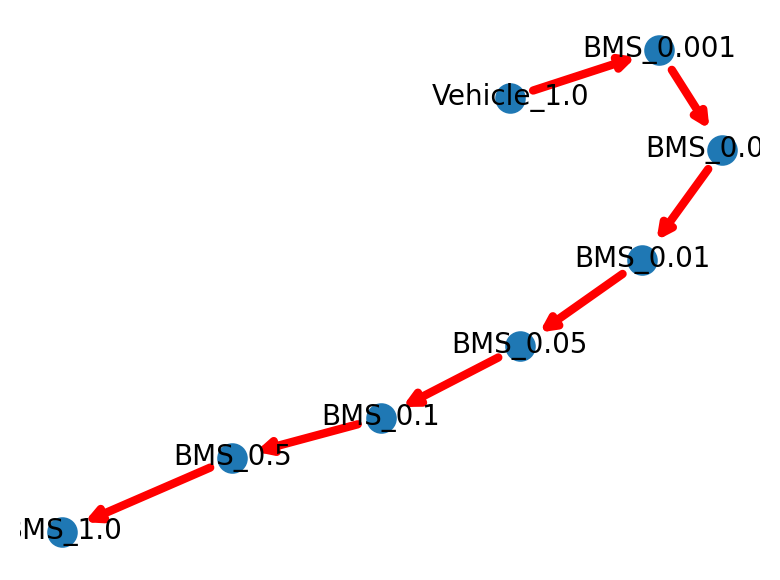

In [9]:
plt.figure(figsize=(4,3))
pos = nx.spring_layout(input_trajectories)  # positions for all nodes
nx.draw_networkx_nodes(input_trajectories, pos, node_size=100)
for u, v, data in input_trajectories.edges(data=True):
    nx.draw_networkx_edges(input_trajectories, pos, edgelist=[(u, v)], width=3, edge_color='red')
nx.draw_networkx_labels(input_trajectories, pos, font_size=10)
plt.axis("off")
plt.tight_layout()
plt.show()

# DPT

In [10]:
adata = ad.AnnData(X=adata_bms.obsm["tardis"][:,:16].copy(), obs=adata_bms.obs.copy())

root_label = "Vehicle_1.0"

iroot_params = {
    "label_key": "labels",
    "label": root_label,
    "method": "centroid",
    "outlier_definition_z": 3
}

dpt_inference = DPTInference(
    random_state=42, 
    neighbors_params={"n_neighbors": 90},
    iroot_params=iroot_params,
    adata=adata, 
    labels=adata.obs["drug_dose_name"]
)

dpt_inference.calculate()
# the same operation in the `infer` example notebook.

2025-03-07 18:11:57.404 | DEBUG    | sctram.infer._base:_initialize_from_adata_without_neighbors:161 - Initializing from AnnData without precomputed neighbors.
2025-03-07 18:11:57.405 | DEBUG    | sctram.infer._base:_add_labels_to_adata:220 - Adding provided labels to AnnData object.
2025-03-07 18:11:57.406 | INFO     | sctram.infer._base:_initialize_from_adata_without_neighbors:168 - No precomputed neighbors found in AnnData.
2025-03-07 18:11:57.406 | DEBUG    | sctram.infer._base:_initialize_from_adata_without_neighbors:172 - AnnData initialized successfully from AnnData without neighbors.
2025-03-07 18:11:57.406 | INFO     | sctram.infer._base:calculate:496 - Starting DPTInference trajectory inference.
2025-03-07 18:11:57.407 | INFO     | sctram.infer._base:calculate:499 - Performing trajectory inference.
2025-03-07 18:11:57.407 | INFO     | sctram.infer._base:_needs_neighbors:514 - Computing neighbors.
2025-03-07 18:11:57.407 | INFO     | sctram.utils._loguru_scanpy_capture:emit:54

In [11]:
inferred_trajectories = dpt_inference.get_result("vector")

In [12]:
pseudotime_evaluation = PseudotimeValuesEvaluation(
    method_params = dict(
            metrics = [
            # "pearson_correlation",
            # "spearman_correlation",
            # "kendall_correlation",
            # "mse",
            # "mae",
            # "r_squared_with_spline",
            # "r_squared",
            # "concordance_index",
            # "dtw_distance",
            # "wasserstein_distance_pseudotime",
            # "normalized_mutual_information",
            # "mutual_information_kde",
            # "cdf_kolmogorov_smirnov",
            # "cdf_cramer_von_mises",
            "morans_i_pseudotime",
            "gearys_c_pseudotime"
        ]
    ),
    prepare_params=dict(
        converter = dict(
            # method = "spectral",
            root_label = root_label
        )
    )
)

2025-03-07 18:12:00.746 | DEBUG    | sctram.evaluate._pseudotime:__init__:38 - Initialized PseudotimeEvaluation with metrics: ['morans_i_pseudotime', 'gearys_c_pseudotime']


In [13]:
logging.getLogger().setLevel(logging.DEBUG)
try:
    pseudotime_evaluation.evaluate(
        given_trajectory=input_trajectories,
        inferred_trajectory=inferred_trajectories,
        labels=adata.obs["drug_dose_name"].to_numpy()
    )
finally:
    logging.getLogger().setLevel(logging.INFO)

2025-03-07 18:12:02.556 | INFO     | sctram.evaluate._base:evaluate:159 - Starting evaluation with PseudotimeValuesEvaluation.
2025-03-07 18:12:02.556 | DEBUG    | sctram.evaluate._base:evaluate:162 - Verifying given trajectory.
2025-03-07 18:12:02.557 | DEBUG    | sctram.evaluate._base:evaluate:165 - Verifying inferred trajectory.
2025-03-07 18:12:02.557 | DEBUG    | sctram.evaluate._base:evaluate:169 - Verifying labels.
2025-03-07 18:12:02.558 | DEBUG    | sctram.evaluate._pseudotime:_verify_labels_data_specific:74 - Checking the consistency between the given graph and labels.
2025-03-07 18:12:02.558 | DEBUG    | sctram.evaluate._base:evaluate:192 - Preparing trajectories after subsetting.
2025-03-07 18:12:02.558 | DEBUG    | sctram.evaluate._pseudotime:_prepare_after_subset:255 - Converting `InputTrajectory` to adjacency matrix.
2025-03-07 18:12:02.560 | DEBUG    | sctram.evaluate._pseudotime:_prepare_after_subset:260 - Initializing `LabelAdjacencyPseudotimeConverter`.
2025-03-07 18

In [14]:
pseudotime_evaluation.get_result()

{'morans_i_pseudotime': 0.006120956916551179,
 'gearys_c_pseudotime': 0.8745690659509774}

In [15]:
pd.DataFrame([pseudotime_evaluation.prepared_after_subset_inferred  , pseudotime_evaluation.subset_labels]).T.groupby(by=1).mean()

,0
1,
BMS_0.001,0.671768
BMS_0.005,0.764818
BMS_0.01,0.837035
BMS_0.05,0.903001
BMS_0.1,0.930256
BMS_0.5,0.923623
BMS_1.0,0.967662
Vehicle_1.0,0.114986


In [16]:
pd.DataFrame([pseudotime_evaluation.prepared_after_subset_given, pseudotime_evaluation.subset_labels]).T.groupby(by=1).mean()

,0
1,
BMS_0.001,0.464194
BMS_0.005,0.856576
BMS_0.01,0.961714
BMS_0.05,0.989883
BMS_0.1,0.997421
BMS_0.5,0.999405
BMS_1.0,1.0
Vehicle_1.0,0.0
